<h1 align="center">Universidad de Buenos Aires</h1>
<h2 align="center">Laboratorio de Sistemas Embebidos</h2>
<h2 align="center">Especialización en Inteligencia Artificial</h2>

<p align="center"><strong>Probabilidad y Estadística para la Inteligencia Artificial</strong></p>

<p align="left">
Nombre: Luis Jose Paredes Ramirez </br>
Codigo: a2627 </br>
Fecha: 16-08-2026
</p>

# Enunciado

Siguiendo con la historia de Don Francisco, con el tiempo y gracias a los análisis de Matías, el pequeño comerciante de barrio cuenta hoy con 5 supermercados: *'Santa Ana'*, *'La Floresta'*, *'Los Cedros'*, *'Palermo'* y *'Córdoba'*.

También Matías ha avanzado en la Especialización en Inteligencia Artificial. Un día Don Francisco le plantea algunas inquietudes adicionales:

1. Don Francisco quiere entender mejor la afluencia de clientes por mes del supermercado *'Santa Ana'*.

2. Más aún, Don Francisco no sabe si puede estar seguro de que la afluencia de clientes son las mismas en todos los supermercados o si hay alguno que se comporte mejor que los demás, y si alguna de las tiendas necesita más atención porque está recibiendo menos clientes que las de las otras.

Con base en lo anterior,

1. (2.5 puntos) Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco, usando distribuciones **Poisson**, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

**Efecto anual:**

| Año | Efecto |
|-----|--------|
| 2023 | 1000 |
| 2024 | 1500 |
| 2025 | 2000 |

**Efecto mensual:**

| Mes | Efecto |
|-----|--------|
| Enero | 1000 |
| Febrero | 1500 |
| Marzo | 2000 |
| Abril | 2000 |
| Mayo | 2500 |
| Junio | 2500 |
| Julio | 3000 |
| Agosto | 2500 |
| Septiembre | 2500 |
| Octubre | 2000 |
| Noviembre | 1500 |
| Diciembre | 1000 |

**Efecto diario:**

| Día | Efecto |
|-----|--------|
| Domingo | 1000 |
| Lunes | 2000 |
| Martes | 3000 |
| Miércoles | 3500 |
| Jueves | 3000 |
| Viernes | 2000 |
| Sábado | 1000 |

**Efecto por tienda:**

| Tienda | Efecto |
|--------|--------|
| Santa Ana | 5000 |
| La Floresta | 2000 |
| Los Cedros | 3000 |
| Palermo | 1000 |
| Córdoba | 3000 |


2. (2.5 puntos) Con base en los datos generados, determinen **intervalos de confianza empíricos** para el supermercado *'Santa Ana'* en cada mes, para significancias del **95 %** y el **99 %**.


3. (2.5 puntos) De igual manera, realicen pruebas **ANOVA** para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del **95 %**.


4. (2.5 puntos) Finalmente, identifiquen la tienda con **mayor promedio** y la tienda con **menor promedio** de clientes y realicen una **prueba de hipótesis** para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.


## Entregables

Deben realizar un informe en un documento **PDF**, en donde queden claros los siguientes aspectos:

1. Planteamiento de los problemas de investigación
2. Procesamiento realizado a los datos
3. Resultados encontrados
4. Análisis y conclusiones

Deben entregar también el **código** utilizado en el proceso.

**¡Muchos éxitos!!**

---

In [1]:
import numpy as np
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

SEED = 42 # para reproducibilidad
rng = np.random.default_rng(SEED)

# Punto 1

Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco, usando distribuciones **Poisson**, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

In [2]:
# Año: Efecto
efecto_anual = {
    2023: 1000,
    2024: 1500,
    2025: 2000
}

# Mes: Efecto
efecto_mensual = {
    1: 1000, # Enero
    2: 1500, # Febrero
    3: 2000, # Marzo
    4: 2000, # Abril
    5: 2500, # Mayo
    6: 2500, # Junio
    7: 3000, # Julio
    8: 2500, # Agosto
    9: 2500, # Septiembre
    10: 2000, # Octubre
    11: 1500, # Noviembre
    12: 1000 # Diciembre
}

# Dia: Efecto
efecto_diario = {
    0: 2000, # Lunes
    1: 3000, # Martes
    2: 3500, # Miercoles
    3: 3000, # Jueves
    4: 2000, # Viernes
    5: 1000, # Sabado
    6: 1000 # Domingo
}

# Tienda: Efecto
efecto_por_tienda = {
    "Santa Ana": 5000,
    "La Floresta": 2000,
    "Los Cedros": 3000,
    "Palermo": 1000,
    "Cordoba": 3000
}

Definimos la variable aleatoria:

$X_{ij}$: el numero de clientes que van en la fecha $i$ al almacen $j$

Asumiendo que el numero de clientes que van diariamente a los almacenes de Don Francisco son independientes, entonces $X_{ij} \overset{\text{iid}}{\sim} \textrm{Poisson}(\lambda_t)$

Se construye una fila por cada combinacion **fecha $\times$ tienda** desde el **2023-01-01** hasta el **2025-12-31**

In [3]:
# Fechas de simulacion
fechas = pd.date_range("2023-01-01", "2025-12-31", freq="D")
efectos = pd.DataFrame({"fecha": fechas})
efectos["anio"] = efectos.fecha.dt.year
efectos["mes"] = efectos.fecha.dt.month
efectos["dia"] = efectos.fecha.dt.day

# Efectos (enunciado)
efectos["ef_anual"] = efectos.anio.map(lambda x: efecto_anual[x])
efectos["ef_mensual"] = efectos.mes.map(lambda x: efecto_mensual[x])
efectos["ef_diario"] = efectos.dia.map(lambda x: efecto_diario[x%7])

# Producto cartesiano efectos × tiendas
efectos = efectos.merge(
    pd.Series(efecto_por_tienda, name="ef_tienda").rename_axis("tienda").reset_index(),
    how="cross"
)

print(f"Total de dias simulados: {len(efectos['fecha'].unique())}. Rango: ({fechas.min().date()}, {fechas.max().date()})")
print(f"Total de observaciones: {efectos.shape[0]}")
efectos.head(10)

Total de dias simulados: 1096. Rango: (2023-01-01, 2025-12-31)
Total de observaciones: 5480


,fecha,anio,mes,dia,ef_anual,ef_mensual,ef_diario,tienda,ef_tienda
0,2023-01-01,2023,1,1,1000,1000,3000,Santa Ana,5000
1,2023-01-01,2023,1,1,1000,1000,3000,La Floresta,2000
2,2023-01-01,2023,1,1,1000,1000,3000,Los Cedros,3000
3,2023-01-01,2023,1,1,1000,1000,3000,Palermo,1000
4,2023-01-01,2023,1,1,1000,1000,3000,Cordoba,3000
5,2023-01-02,2023,1,2,1000,1000,3500,Santa Ana,5000
6,2023-01-02,2023,1,2,1000,1000,3500,La Floresta,2000
7,2023-01-02,2023,1,2,1000,1000,3500,Los Cedros,3000
8,2023-01-02,2023,1,2,1000,1000,3500,Palermo,1000
9,2023-01-02,2023,1,2,1000,1000,3500,Cordoba,3000


Para cada fila calculamos $\lambda_t$ como:

$$\lambda_t = \text{efecto\_anual}(\text{año}) + \text{efecto\_mensual}(\text{mes}) + \text{efecto\_diario}(\text{día de semana}) + \text{efecto\_tienda}(\text{tienda})$$


y luego el numero de clientes se muestrea como $\;\text{clientes} \overset{\text{iid}}{\sim} \text{Poisson}(\lambda_t)$.

In [4]:
efectos["lambda_t"] = efectos.apply(
    lambda row: row.ef_anual + row.ef_mensual + row.ef_diario + row.ef_tienda, 
    axis=1
)

# Los clientes se distribuyen segun la distribucion de Poisson(lambda_t)
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.poisson.html
efectos["clientes"] = rng.poisson(efectos["lambda_t"].to_numpy())

efectos.head(10)

,fecha,anio,mes,dia,ef_anual,ef_mensual,ef_diario,tienda,ef_tienda,lambda_t,clientes
0,2023-01-01,2023,1,1,1000,1000,3000,Santa Ana,5000,10000,10085
1,2023-01-01,2023,1,1,1000,1000,3000,La Floresta,2000,7000,7103
2,2023-01-01,2023,1,1,1000,1000,3000,Los Cedros,3000,8000,7860
3,2023-01-01,2023,1,1,1000,1000,3000,Palermo,1000,6000,6062
4,2023-01-01,2023,1,1,1000,1000,3000,Cordoba,3000,8000,7883
5,2023-01-02,2023,1,2,1000,1000,3500,Santa Ana,5000,10500,10462
6,2023-01-02,2023,1,2,1000,1000,3500,La Floresta,2000,7500,7536
7,2023-01-02,2023,1,2,1000,1000,3500,Los Cedros,3000,8500,8485
8,2023-01-02,2023,1,2,1000,1000,3500,Palermo,1000,6500,6512
9,2023-01-02,2023,1,2,1000,1000,3500,Cordoba,3000,8500,8599


**Resultado P1.** 

Luego de la simulacion, nos quedamos con un conjunto de **5.480 observaciones** (1.096 días × 5 tiendas) de clientes que van a las distintas tiendas diaremente, siguiendo una distribucion $\overset{\text{iid}}{\sim} \text{Poisson}(\lambda_t)$. 

---



# Punto 2

Con base en los datos generados, determinen **intervalos de confianza empíricos** para el supermercado *'Santa Ana'* en cada mes, para significancias del **95%** y el **99%**.

In [5]:
def intervalo_confianza_empirico(x: np.array, confianza: float):
    """IC empírico via percentiles de la muestra (no asume normalidad)."""
    alpha = 1 - confianza
    lo, hi = np.percentile(x, [100*alpha/2, 100*(1-alpha/2)])
    return lo, hi

def resumen_mes(x: np.array):
    ic95_lo, ic95_hi = intervalo_confianza_empirico(x, 0.95)
    ic99_lo, ic99_hi = intervalo_confianza_empirico(x, 0.99)
    return pd.Series({
        "n": len(x),
        "media": x.mean(),
        "std": x.std(ddof=1),
        "ic95_lo": ic95_lo,
        "ic95_hi": ic95_hi,
        "ic99_lo": ic99_lo,
        "ic99_hi": ic99_hi,
    })


# filtramos los datos para el supermercado 'Santa Ana'
efectos_santa_ana = efectos[efectos['tienda'] == 'Santa Ana'].reset_index(drop=True)

# Determinamos los intervalos de confianza 0.95 & 0.99 en cada mes para los clientes de la tienda Santa Ana
resumen_santa_ana = (
    efectos_santa_ana
    .groupby("mes")["clientes"]
    .apply(resumen_mes)
    .unstack() # .pivot()
    .reset_index()
)

resumen_santa_ana

,mes,n,media,std,ic95_lo,ic95_hi,ic99_lo,ic99_hi
0,1,93.0,9804.655914,1020.997354,7932.600,11523.300,7863.880,11661.980
1,2,85.0,10229.670588,1008.359304,8524.300,11972.600,8474.040,12106.480
2,3,93.0,10814.677419,1026.739385,8989.000,12491.800,8971.000,12593.980
3,4,90.0,10776.533333,1004.454620,8990.850,12404.075,8843.620,12595.255
4,5,93.0,11308.870968,1012.869205,9479.300,12879.300,9419.560,12983.980
5,6,90.0,11269.166667,1017.892339,9461.525,12888.500,9412.890,12984.090
6,7,93.0,11809.086022,995.283002,10023.600,13352.900,9912.900,13453.140
7,8,93.0,11295.967742,1010.766707,9478.400,13005.200,9427.520,13096.860
8,9,90.0,11275.844444,1021.755527,9443.525,12986.275,9308.005,13137.865
9,10,93.0,10812.000000,997.743389,9007.400,12482.400,8889.800,12604.460


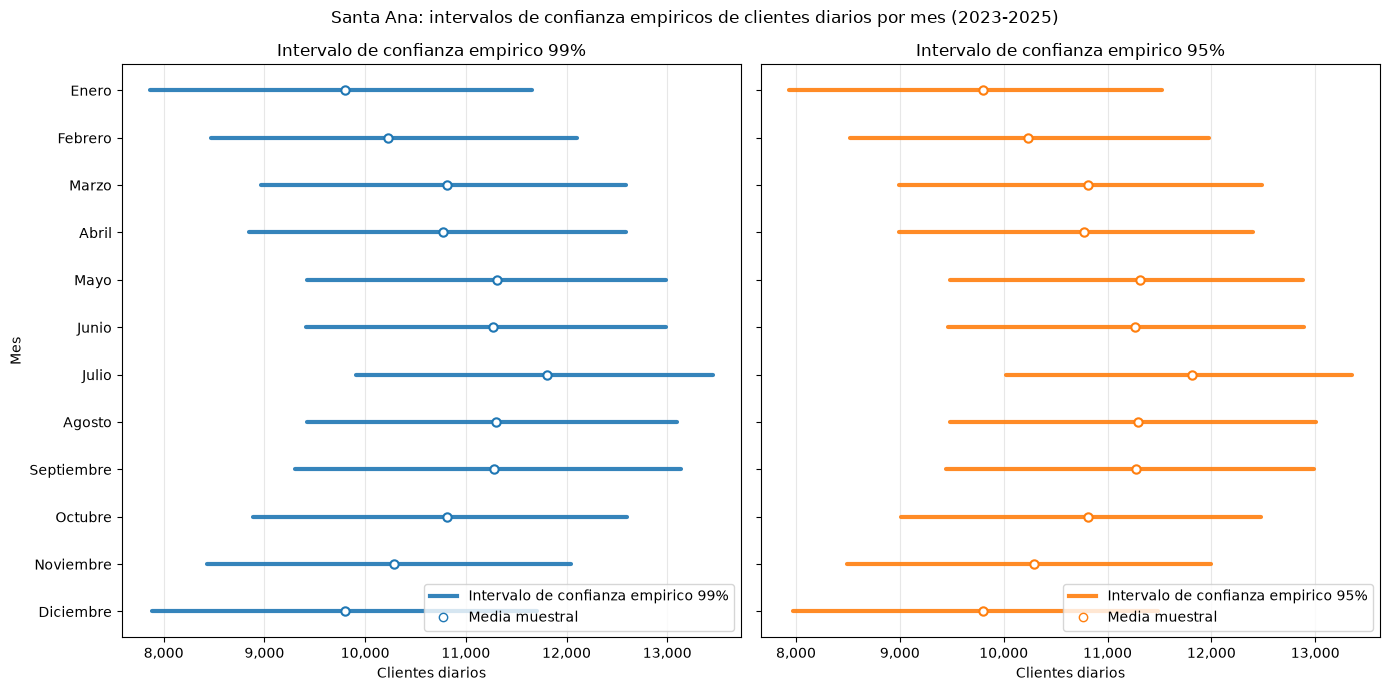

In [6]:
meses_map = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 
             7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}

fig, (ax99, ax95) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

paneles = [
    (ax99, "ic99_lo", "ic99_hi", "tab:blue", "Intervalo de confianza empirico 99%"),
    (ax95, "ic95_lo", "ic95_hi", "tab:orange", "Intervalo de confianza empirico 95%"),
]

for ax, col_lo, col_hi, color, titulo in paneles:
    for _, row in resumen_santa_ana.iterrows():
        y = row["mes"]
        ax.plot([row[col_lo], row[col_hi]], [y, y], color=color, alpha=0.9, linewidth=3, solid_capstyle="round")
        ax.plot(row["media"], y, "o", color="white", markeredgecolor=color, markeredgewidth=1.5, zorder=3)

    ax.set_xlabel("Clientes diarios")
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="x", alpha=0.3)
    ax.legend(handles=[
        Line2D([0], [0], color=color, alpha=0.9, linewidth=3, label=titulo),
        Line2D([0], [0], marker="o", color="white", markeredgecolor=color, linestyle="", label="Media muestral")
    ], loc="lower right")

ax99.set_yticks(list(meses_map.keys()))
ax99.set_yticklabels(list(meses_map.values()))
ax99.set_ylabel("Mes")
ax99.invert_yaxis()  # Enero arriba, Diciembre abajo

fig.suptitle("Santa Ana: intervalos de confianza empiricos de clientes diarios por mes (2023-2025)")
plt.tight_layout()
plt.show()

**Resultado P2.**

Para cada mes se calculó el intervalo de confianza **empírico** de los clientes diarios de *'Santa Ana'* usando el método de percentiles sobre la muestra observada (percentiles $\alpha/2$ y $1-\alpha/2$ de las 90-93 observaciones diarias que caen en ese mes a lo largo de 2023-2025), sin asumir normalidad.

Se observa que:
- Los meses con mayor afluencia media (Julio, Agosto, Septiembre) presentan intervalos centrados en valores más altos, consistente con su mayor efecto mensual ($\lambda$ base más alto).
- El intervalo al 99% es, como es esperable, más ancho que el del 95% en todos los meses, ya que exige mayor cobertura de la distribución empírica.
- Al ser Poisson con $\lambda$ grande (aprox. 9.000-13.000 según el mes), la dispersión relativa es baja: los IC resultan relativamente angostos en términos porcentuales respecto a la media ($\sigma \approx \sqrt{\lambda}$).

---


# Punto 3

De igual manera, realicen pruebas **ANOVA** para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del **95%**.

Antes de empezar veamos empiricamente la media y varianza de la muestra con que trabajaremos

In [7]:
resumen_tiendas = (
    efectos.groupby("tienda")["clientes"]
    .agg(n="count", media="mean", std=lambda x: x.std(ddof=1))
    .reindex(list(efecto_por_tienda.keys()))  # mantenemos el orden de definicion
    .reset_index()
)
resumen_tiendas

,tienda,n,media,std
0,Santa Ana,1096,10793.655109,1182.567982
1,La Floresta,1096,7794.527372,1193.798096
2,Los Cedros,1096,8792.375000,1190.732895
3,Palermo,1096,6792.137774,1186.703264
4,Cordoba,1096,8795.472628,1183.133705


Planteamos las hipotesis:

$$H_0: \mu_{\text{Santa Ana}} = \mu_{\text{La Floresta}} = \mu_{\text{Los Cedros}} = \mu_{\text{Palermo}} = \mu_{\text{Cordoba}}$$
$$H_1: \text{al menos una media difiere de las demas}$$

con $\alpha = 0.05$. 

Antes de aplicar ANOVA realizamos los siguientes supuestos: 
- Cada evento es independiente
- Con $n=1096$ fechas por tienda y $\lambda_t$ grande, la Poisson se aproxima a una normal por teorema central del limite
- y homogeneidad de varianzas

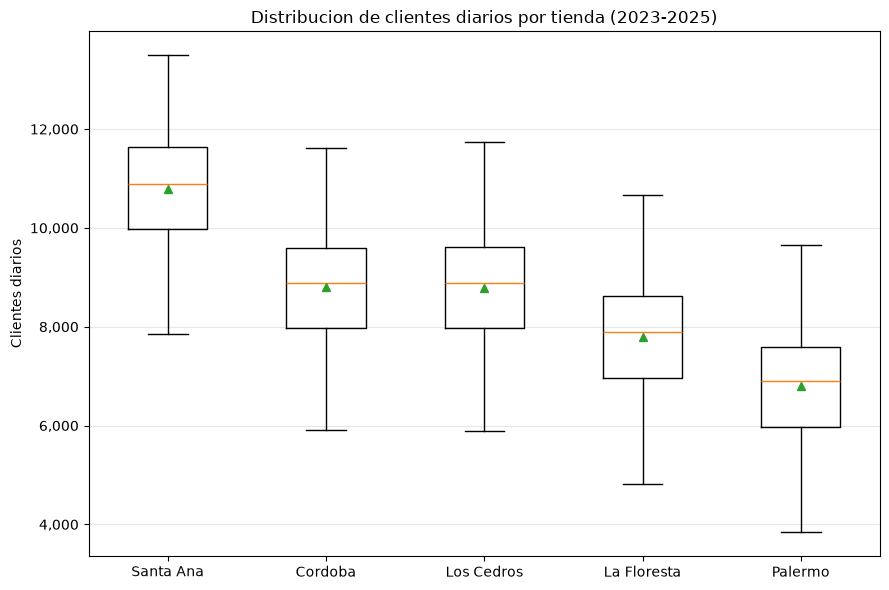

In [8]:
orden_tiendas = resumen_tiendas.sort_values("media", ascending=False)["tienda"].tolist()
datos_ordenados = [efectos.loc[efectos["tienda"] == t, "clientes"].values for t in orden_tiendas]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(datos_ordenados, tick_labels=orden_tiendas, showmeans=True)
ax.set_ylabel("Clientes diarios")
ax.set_title("Distribucion de clientes diarios por tienda (2023-2025)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
grupos = [efectos.loc[efectos["tienda"] == t, "clientes"].values for t in efecto_por_tienda.keys()]

f_stat, p_anova = st.f_oneway(*grupos)
alpha = 0.05

print(f"ANOVA de un factor (tienda): F = {f_stat:.4f}, p-valor = {p_anova:.4g}")
if p_anova < alpha:
    print(f"p-valor < {alpha}: rechazamos H0. Al menos una tienda tiene un promedio de clientes distinto de las demas.")
else:
    print(f"p-valor >= {alpha}: no hay evidencia suficiente para rechazar H0.")

ANOVA de un factor (tienda): F = 1711.0172, p-valor = 0
p-valor < 0.05: rechazamos H0. Al menos una tienda tiene un promedio de clientes distinto de las demas.


Dado que se rechaza $H_0$, aplicamos un test **post hoc de Tukey HSD** para identificar que pares de tiendas difieren entre si.

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(efectos["clientes"], efectos["tienda"], alpha=0.05)
print(tukey.summary())

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1      group2    meandiff  p-adj   lower      upper    reject
---------------------------------------------------------------------
    Cordoba La Floresta -1000.9453   0.0 -1139.3523  -862.5382   True
    Cordoba  Los Cedros    -3.0976   1.0  -141.5047   135.3094  False
    Cordoba     Palermo -2003.3349   0.0 -2141.7419 -1864.9278   True
    Cordoba   Santa Ana  1998.1825   0.0  1859.7754  2136.5895   True
La Floresta  Los Cedros   997.8476   0.0   859.4406  1136.2547   True
La Floresta     Palermo -1002.3896   0.0 -1140.7967  -863.9825   True
La Floresta   Santa Ana  2999.1277   0.0  2860.7207  3137.5348   True
 Los Cedros     Palermo -2000.2372   0.0 -2138.6443 -1861.8302   True
 Los Cedros   Santa Ana  2001.2801   0.0   1862.873  2139.6872   True
    Palermo   Santa Ana  4001.5173   0.0  3863.1103  4139.9244   True
---------------------------------------------------------------------


**Resultado P3.**

- El ANOVA de un factor da $F \approx 1711$, $p \approx 0$, muy por debajo de $\alpha = 0.05$: **se rechaza $H_0$**. Por ende tenemos evidencia estadisticamente fuerte de que el promedio de clientes no es el mismo en todas las tiendas.
- El post-hoc de Tukey HSD muestra que **todos los pares de tiendas difieren significativamente entre si, excepto Cordoba vs. Los Cedros**, consistente con que ambas comparten el mismo efecto de tienda simulado (3000).
- El orden de medias observado, Santa Ana > Cordoba ~ Los Cedros > La Floresta > Palermo, coincide exactamente con el orden de los efectos por tienda definidos en la simulacion (5000, 3000, 3000, 2000, 1000).

---


# Punto 4

Finalmente, identifiquen la tienda con **mayor promedio** y la tienda con **menor promedio** de clientes y realicen una **prueba de hipótesis** para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.

In [11]:
tienda_max = resumen_tiendas.loc[resumen_tiendas["media"].idxmax(), "tienda"]
tienda_min = resumen_tiendas.loc[resumen_tiendas["media"].idxmin(), "tienda"]

media_max = resumen_tiendas.set_index("tienda").loc[tienda_max, "media"]
media_min = resumen_tiendas.set_index("tienda").loc[tienda_min, "media"]

print(f"Tienda con mayor promedio de clientes: {tienda_max} (media = {media_max:,.2f})")
print(f"Tienda con menor promedio de clientes: {tienda_min} (media = {media_min:,.2f})")

Tienda con mayor promedio de clientes: Santa Ana (media = 10,793.66)
Tienda con menor promedio de clientes: Palermo (media = 6,792.14)


Planteamos el contraste de hipotesis para la diferencia de medias entre la tienda de mayor y la de menor promedio:

$$H_0: \mu_{\text{max}} - \mu_{\text{min}} = 0$$
$$H_1: \mu_{\text{max}} - \mu_{\text{min}} \neq 0$$

con $\alpha = 0.05$. Usamos un [t de Student](https://es.wikipedia.org/wiki/Prueba_t_de_Student) para comparar dos grupos independientes

In [12]:
clientes_max = efectos.loc[efectos["tienda"] == tienda_max, "clientes"].values
clientes_min = efectos.loc[efectos["tienda"] == tienda_min, "clientes"].values

t_stat, p_valor = st.ttest_ind(clientes_max, clientes_min, equal_var=False)
diferencia_medias = clientes_max.mean() - clientes_min.mean()
alpha = 0.05

print(f"Diferencia observada de medias ({tienda_max} - {tienda_min}): {diferencia_medias:,.2f} clientes/dia")
print(f"t = {t_stat:.4f}, p-valor = {p_valor:.4g}")

if p_valor < alpha:
    print(f"p-valor < {alpha}: rechazamos H0. La diferencia de medias es significativamente distinta de cero.")
else:
    print(f"p-valor >= {alpha}: no hay evidencia suficiente para rechazar H0.")

Diferencia observada de medias (Santa Ana - Palermo): 4,001.52 clientes/dia
t = 79.0732, p-valor = 0
p-valor < 0.05: rechazamos H0. La diferencia de medias es significativamente distinta de cero.


In [13]:
tienda_max_efecto = max(efecto_por_tienda, key=efecto_por_tienda.get)
tienda_min_efecto = min(efecto_por_tienda, key=efecto_por_tienda.get)

print(f"Tienda con mayor efecto simulado: {tienda_max_efecto} (efecto = {efecto_por_tienda[tienda_max_efecto]})")
print(f"Tienda con menor efecto simulado: {tienda_min_efecto} (efecto = {efecto_por_tienda[tienda_min_efecto]})\n")

print(f"Coincide la tienda de mayor promedio observado con la de mayor efecto: {tienda_max == tienda_max_efecto}")
print(f"Coincide la tienda de menor promedio observado con la de menor efecto: {tienda_min == tienda_min_efecto}")

Tienda con mayor efecto simulado: Santa Ana (efecto = 5000)
Tienda con menor efecto simulado: Palermo (efecto = 1000)

Coincide la tienda de mayor promedio observado con la de mayor efecto: True
Coincide la tienda de menor promedio observado con la de menor efecto: True


**Resultado P4.**

- La tienda con **mayor promedio** de clientes diarios es **Santa Ana** (media ~ 10.793,66) y la de **menor promedio** es **Palermo** (media ~ 6.792,14).
- El t de Student da $t \approx 79.07$, $p \approx 0$, muy por debajo de $\alpha = 0.05$. Por ende **se rechaza $H_0$**
- Ambas tiendas identificadas coinciden exactamente con las de **mayor y menor efecto de tienda simulado** (Santa Ana = 5000, Palermo = 1000). De esta forma confirmamos que la simulacion refleja fielmente los efectos definidos y que la tienda en Palermo necesita mas atencion por recibir sistematicamente menos clientes que el resto.

---
